In [3]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
SQLITE_PATH = "/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/db.sqlite"
# SQLITE_PATH = "db.sqlite"

BODY_PREVIEW_CHARS = 2000
news_articles = "articles"


# Batch size for zero-shot classification (lower if you run out of RAM)
CLASSIFICATION_BATCH_SIZE = 32

In [6]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [7]:
query = f"SELECT * FROM {news_articles}"


df = pd.read_sql_query(query, conn)



In [8]:
df["combined_text"] = (
	df["title"].fillna("") + " " +
	df["text"].fillna("").str[:BODY_PREVIEW_CHARS]
).str.strip()

In [9]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")  # ~80MB, fast, good quality

texts = df["combined_text"].tolist()
embeddings = model.encode(
	texts,
	batch_size=64,
	show_progress_bar=True,
	convert_to_numpy=True,
)


embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

array([[-0.06131215, -0.06832996,  0.01028383, ..., -0.02049773,
         0.03828378, -0.04221653],
       [-0.08706728, -0.03810881,  0.06855407, ..., -0.05453417,
         0.02314829, -0.02113674],
       [ 0.0489215 , -0.0552038 , -0.01745365, ...,  0.02567567,
         0.07416613, -0.04599846],
       ...,
       [-0.0197321 , -0.07804197, -0.01793773, ..., -0.13375318,
        -0.06402431,  0.10456637],
       [ 0.01870184, -0.12493677, -0.00209158, ..., -0.03907901,
         0.00521955,  0.05578442],
       [-0.02489518, -0.09354517,  0.03182888, ..., -0.05169712,
        -0.02789778, -0.01350779]], dtype=float32)

In [10]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

n_clusters = 10


# Reduce dims first for speed
pca = PCA(n_components=50, random_state=42)
reduced = pca.fit_transform(embeddings)

km = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=3)
labels = km.fit_predict(reduced)

unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
	print(f"   Cluster {u:2d}: {c:,} articles")


labels

   Cluster  0: 1,225 articles
   Cluster  1: 1,840 articles
   Cluster  2: 1,296 articles
   Cluster  3: 1,800 articles
   Cluster  4: 1,318 articles
   Cluster  5: 772 articles
   Cluster  6: 1,848 articles
   Cluster  7: 1,840 articles
   Cluster  8: 1,180 articles
   Cluster  9: 1,904 articles


array([6, 7, 5, ..., 4, 4, 9], dtype=int32)

In [11]:
from sklearn.preprocessing import normalize

# Define the target theme as a natural language query
TARGET_THEME = "AI use impact on society, environment, law, and jobs"

from sentence_transformers import SentenceTransformer
_model = SentenceTransformer("all-MiniLM-L6-v2")
theme_embedding = _model.encode([TARGET_THEME], convert_to_numpy=True)

# Compute cluster centroids in original embedding space
n_c = n_clusters
centroids = np.array([
    embeddings[labels == c].mean(axis=0) for c in range(n_c)
])

# Cosine similarity between theme and each centroid
norm_centroids = normalize(centroids)
norm_theme = normalize(theme_embedding)
cosine_sims = (norm_centroids @ norm_theme.T).flatten()

# Rank clusters by similarity
ranked = sorted(enumerate(cosine_sims), key=lambda x: -x[1])
print("Cluster similarity to target theme:")
for cluster_id, sim in ranked:
    print(f"  Cluster {cluster_id:2d}: {sim:.4f}  ({counts[cluster_id]:,} articles)")

# Auto-select top clusters above a similarity threshold
SIM_THRESHOLD = 0.5
relevant_clusters = [c for c, s in ranked if s >= SIM_THRESHOLD]
print(f"\nAuto-selected clusters: {relevant_clusters}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cluster similarity to target theme:
  Cluster  7: 0.6482  (1,840 articles)
  Cluster  9: 0.6401  (1,904 articles)
  Cluster  6: 0.6263  (1,848 articles)
  Cluster  3: 0.6227  (1,800 articles)
  Cluster  0: 0.5563  (1,225 articles)
  Cluster  1: 0.5067  (1,840 articles)
  Cluster  5: 0.4951  (772 articles)
  Cluster  2: 0.4806  (1,296 articles)
  Cluster  8: 0.3671  (1,180 articles)
  Cluster  4: 0.3485  (1,318 articles)

Auto-selected clusters: [7, 9, 6, 3, 0, 1]


In [12]:
df_all_copy = df.copy()
df_all_copy["cluster"] = labels

# Print sample articles from each selected cluster for sanity check
n_samples = 10
for cluster_id in relevant_clusters:
    samples = df_all_copy[df_all_copy["cluster"] == cluster_id]["combined_text"].head(n_samples).tolist()
    print(f"\n── Cluster {cluster_id} (sim={cosine_sims[cluster_id]:.3f}) ──")
    for s in samples:
        print(f"  • {s[:120]}")


── Cluster 7 (sim=0.648) ──
  • Will your job survive Trump’s Gen AI revolution? The Trump administration’s recent announcement of a sweeping deregulato
  • As a Berkeley professor, I see the impact H-1B visas and AI have on students' job opportunities The H-1B visa program wa
  • The impending AI-driven jobless economy: Who will pay taxes? Our socioeconomic system is facing an existential threat fr
  • Forget AI, these dirty jobs will help you clean up For years, we’ve been told the future belongs to tech jobs, coding bo
  • Fear of becoming obsolete: How to hedge against AI stealing your job - ET Telecom - Internet
- 5 min read
Fear of beco
  • If AI doesn't kill your company, it will make it stronger, study shows - ET CIO - Artificial Intelligence
- 1 min read
  • Alphabet to keep hiring engineers while AI advances - ET Telecom - Internet
- 2 min read
Alphabet to keep hiring engin
  • AI risks 'broken' career ladder for college graduates, some experts say AI risks 'broken' career l

In [13]:

# Filtered df with only relevant clusters
df_filtered = df_all_copy[df_all_copy["cluster"].isin(relevant_clusters)].copy()

print(f"Original articles: {len(df_all_copy)}")
print(f"Filtered articles: {len(df_filtered)}")
print(f"Removed: {len(df_all_copy) - len(df_filtered)}")


Original articles: 15023
Filtered articles: 10457
Removed: 4566


In [14]:
CANDIDATE_LABELS_PRIMARY = [
    "a coding tutorial, technical guide, or software implementation walkthrough with little discussion of societal implications",
    "an opinion piece, analysis, or commentary on AI's consequences for society, law, environment, or ethics",
]


CANDIDATE_LABELS_SECONDARY = [
    "discussion of the environmental impact or energy consumption of AI",
    "discussion of legal, regulatory, or policy issues related to AI",
    "discussion of ethical concerns, bias, or fairness in AI systems",
    "discussion of AI's impact on jobs, employment, or the economy",
    "discussion of AI in geopolitics, international competition, or national security",
    "discussion of how AI is portrayed in media or public opinion",
    "discussion of AI safety, alignment, or existential risks",
]


In [15]:
from transformers import pipeline

pipe = pipeline(
	"zero-shot-classification",
	model="facebook/bart-large-mnli",
	device=0,  # CPU; change to 0 if you have a CUDA GPU
)

texts = df_filtered["combined_text"].tolist()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
def classify_batch(pipe, texts, candidate_labels, threshold=0.5, batch_size=16):
    results = pipe(texts, candidate_labels, multi_label=True, batch_size=batch_size)
    if isinstance(results, dict):
        results = [results]
    
    output = []
    for r in results:
        labels_scores = [
            (label, score)
            for label, score in zip(r["labels"], r["scores"])
            if score >= threshold
        ]
        output.append(labels_scores)
    
    return output

In [17]:
secondary_labels = pd.Series("UNSURE", index=df_filtered.index, dtype="object")
secondary_scores = pd.Series(0.0, index=df_filtered.index, dtype="float64")

for i in tqdm(range(0, len(texts), CLASSIFICATION_BATCH_SIZE), desc="Classifying"):
    batch_texts = texts[i:i+CLASSIFICATION_BATCH_SIZE]
    batch_indices = df_filtered.index[i:i+CLASSIFICATION_BATCH_SIZE]
    
    results = pipe(batch_texts, CANDIDATE_LABELS_SECONDARY, multi_label=True)
    if isinstance(results, dict):
        results = [results]

    for idx, r in zip(batch_indices, results):
        top_label = r["labels"][0]
        top_score = r["scores"][0]
        if top_score >= 0.5:
            secondary_labels.loc[idx] = top_label
            secondary_scores.loc[idx] = float(top_score)

df_filtered["secondary_label"] = secondary_labels
df_filtered["secondary_score"] = secondary_scores

Classifying: 100%|██████████| 327/327 [1:02:06<00:00, 11.40s/it]


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,              # increase minimum frequency
    stop_words='english',
    max_features=500,      # fewer features
    ngram_range=(1, 2)     # include bigrams
)

In [19]:
# Vectorize cleaned content
from sklearn.decomposition import LatentDirichletAllocation


vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    min_df=3, # word must appear in at least 5 documents
    max_df=0.5 # word can appear in at most 80% of documents
)
doc_term_matrix = vectorizer.fit_transform(df_filtered['combined_text'])

# Train LDA model
lda = LatentDirichletAllocation(
    n_components=8, # 5 topics
    random_state=42,
    max_iter=100
)
lda.fit(doc_term_matrix)

LatentDirichletAllocation(max_iter=100, n_components=8, random_state=42)

In [20]:
# Display topics
feature_names = vectorizer.get_feature_names_out()

print("Topics discovered:")
for topic_idx, topic in enumerate(lda.components_):
	# get top 10 words for the topiC
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

# Get topic distribution per document
doc_topics = lda.transform(doc_term_matrix)
df_filtered['dominant_topic'] = doc_topics.argmax(axis=1)
df_filtered['dominant_topic_prob'] = doc_topics.max(axis=1)


Topics discovered:
Topic 0: jobs, work, leaders, job, skills, workers, employees, human, talent, tasks
Topic 1: data, learning, machine, systems, security, models, information, human, algorithms, cybersecurity
Topic 2: generative, chatgpt, content, language, models, tools, images, text, like, large
Topic 3: tech, industry, world, year, driving, global, years, power, future, billion
Topic 4: google, openai, company, microsoft, said, chatgpt, chatbot, search, meta, users
Topic 5: business, companies, businesses, customer, cloud, council, company, software, post, services
Topic 6: people, human, like, just, time, said, make, use, think, way
Topic 7: said, china, government, tech, companies, risks, musk, safety, president, systems


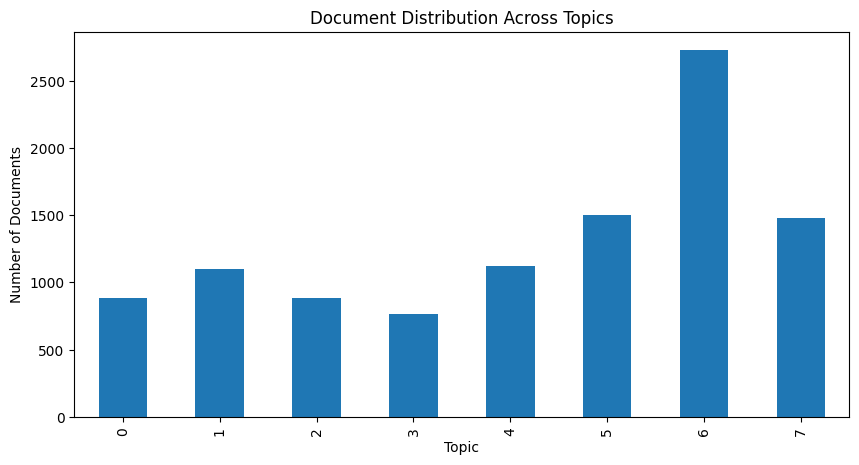

In [21]:
# Visualize topic distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
df_filtered['dominant_topic'].value_counts().sort_index().plot(kind='bar')
plt.title('Document Distribution Across Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Documents')
plt.show()

In [22]:
conn = sqlite3.connect("/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/db.sqlite")
df_filtered.to_sql("modified_articles", conn, if_exists="replace", index=False)
conn.close()